# Retrieval and RAG over tasting notes

Retrieval asks a different question from the models so far: not "what does this prose imply about
price" but "what did wines that taste like this actually cost".

The store holds tasting notes only. No price, no critic score, no winery in the embedded text -- if
those went in, similarity search would find the answer instead of a comparable wine, and the whole
evaluation would be a leak with extra steps. Prices live in the metadata, retrieved *after* the
match, which is how a comparable is supposed to work.

In [11]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

from pricer import vectors
from pricer.agents import ClassicalAgent, FrontierAgent, NeighboursAgent, price_all, setup_logging
from pricer.evaluator import Report, leaderboard
from pricer.items import Wine

setup_logging()
train, val, test = Wine.load_local()
collection = vectors.load()  # built by scripts/vectors.py
encoder = vectors.encoder()
print(f"{collection.count():,} tasting notes embedded")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

79,359 tasting notes embedded


### Does the embedding space know about price?

If wines that taste alike also cost alike, the neighbourhood structure carries price information and
retrieval will help. Colour a t-SNE projection by price and look for gradient rather than noise.

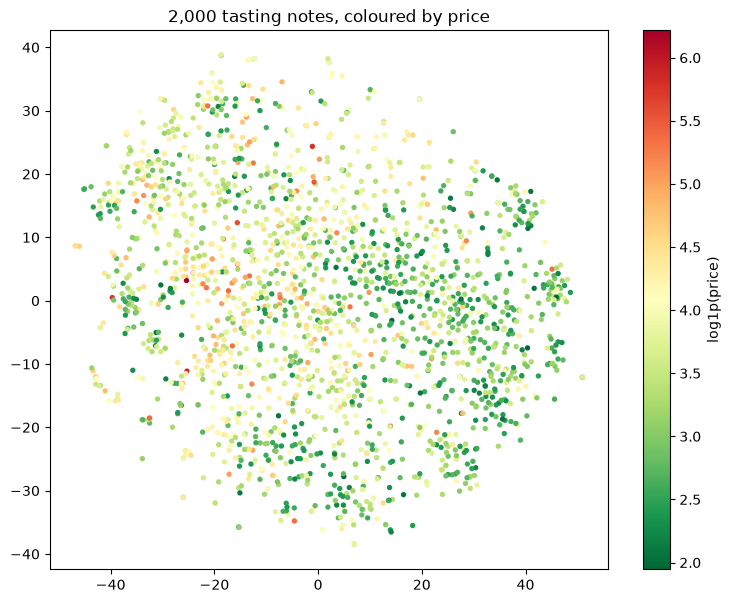

Most common varieties in the sample: [('Pinot Noir', 214), ('Chardonnay', 185), ('Cabernet Sauvignon', 178), ('Red Blend', 140), ('Bordeaux-style Red Blend', 94)]


In [12]:
embeddings, prices, varieties = vectors.sample_coordinates(collection, limit=2_000)
flat = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(embeddings)
plt.figure(figsize=(9, 7))
points = plt.scatter(flat[:, 0], flat[:, 1], c=np.log1p(prices), cmap="RdYlGn_r", s=8)
plt.colorbar(points, label="log1p(price)")
plt.title("2,000 tasting notes, coloured by price")
plt.show()
print("Most common varieties in the sample:", Counter(varieties).most_common(5))

### What does retrieval return for one wine?

In [13]:
wine = test[7]
notes, found = vectors.similar(wine.description, collection, encoder, k=5)
print(f"{wine.label} -- actually ${wine.price:.0f}\n")
for note, price in zip(notes, found, strict=True):
    print(f"${price:>6.0f}  {note[:110]}...")
print(f"\ngeometric mean of the neighbours: ${np.expm1(np.log1p(found).mean()):.2f}")

Espectacle 2010 René Isabelle Christopher Charlotte Fernando Marta Red (Montsant) -- actually $130

$     9  With aromas of blueberry and Kool-Aid, this feels raw and pointy, with basic plum and dry red-fruit flavors. A...
$    10  Smells strange, like a bowl of Smucker's raspberry jam or applesauce. The palate is creamy and dull, with flat...
$    23  This has aromas of smashed berry and red licorice candy. It feels raspy and resiny, with flavors of toasted oa...
$    10  Feels flat and syrupy feeling, with sweet, herb flavors that suggest blueberry and baked plum. Finishes herbal...
$    13  Funky, off-base floral aromas and a sweet, cotton candy flavor profile. Feels flat and sugary to the end, with...

geometric mean of the neighbours: $12.24


### Retrieval alone, then retrieval plus a language model

Two agents, one question each. `NeighboursAgent` is pure retrieval: the geometric mean of the k
nearest prices, no LLM. `FrontierAgent` puts the same neighbours in a prompt and asks a model for a
number. The gap between them is what the language model contributes over the lookup; if it is small,
the expensive part is not earning its keep.

100 test wines, because the frontier agent goes over the network for each one. Note the sample size in
the leaderboard: these rows are not comparable to the 2,000-wine baseline rows, only to each other.

The classical agent here is the **note-only** model, not the metadata-aware baseline. An agent receives prose and
nothing else, so feeding the metadata-aware pipeline `variety='unknown', vintage=0` at inference --
after fitting it on the real values -- cost about 0.2 RMSLE. Train on what you can actually serve.

In [14]:
sample = test[:2000]
neighbours = NeighboursAgent(collection, encoder)
classical = ClassicalAgent()

for name, agent in [("Neighbours (k=8, retrieval only)", neighbours), ("Classical (note only)", classical)]:
    guesses = [agent.price(w.description) for w in sample]
    Report(name, [w.label for w in sample], guesses, [w.price for w in sample]).save()

frontier = FrontierAgent(collection, encoder)
guesses = price_all(frontier, [w.description for w in sample])  # stops early if the daily quota runs out
scored = sample[: len(guesses)]
if scored:
    Report("Frontier (RAG + LLM)", [w.label for w in scored], guesses, [w.price for w in scored]).save()
leaderboard()

12:29:56 [Neighbours Agent] Connecting to the Chroma store
12:29:56 [Neighbours Agent] Ready with 79,359 notes
12:29:56 [Classical Agent] Loading the TF-IDF + Ridge model
12:29:56 [Classical Agent] Ready
12:32:53 [Frontier Agent] Setting up with groq
12:32:53 [Frontier Agent] Ready
12:32:54 [Frontier Agent] Retrieved 5 comparable wines priced $23-$144
12:32:54 [Frontier Agent] Estimated $28.00
12:32:54 [Frontier Agent] Retrieved 5 comparable wines priced $10-$90
12:32:54 [Frontier Agent] Estimated $75.00
12:32:54 [Frontier Agent] Retrieved 5 comparable wines priced $10-$75
12:32:55 [Frontier Agent] Estimated $25.00
12:32:55 [Frontier Agent] Retrieved 5 comparable wines priced $13-$63
12:32:55 [Frontier Agent] Estimated $32.00
12:32:55 [Frontier Agent] Retrieved 5 comparable wines priced $9-$13
12:32:56 [Frontier Agent] Estimated $10.00
12:32:56 [Frontier Agent] Retrieved 5 comparable wines priced $8-$57
12:32:56 [Frontier Agent] Estimated $50.00
12:32:56 [Frontier Agent] Retrieved 5 co

model                                    MAE    RMSLE      R2    hits      n
Modernbert-Large (Full Ft)            12.43    0.367   62.2%   67.5%  2,000
Claude Opus 5                         13.31    0.390   45.3%   64.4%  2,000
Tf-Idf + Ridge                        15.31    0.454   44.4%   58.9%  2,000
Classical (note only)                 16.42    0.495   38.3%   55.5%  2,000
Lsa + Random Forest                   16.57    0.505   34.1%   55.1%  2,000
Metadata + Linear Regression          17.40    0.532   29.2%   52.8%  2,000
Neighbours (k=8, retrieval only)      17.99    0.555   25.5%   53.2%  2,000
Constant $30                          23.96    0.749   -7.7%   29.6%  2,000
Frontier (RAG + LLM)                  20.81    0.788   21.2%   44.0%    375


### Experiments worth running here

- Sweep `k` in `NeighboursAgent`. Too few neighbours is noisy, too many regresses to the mean.
- Weight the neighbours by similarity instead of averaging them flat.
- Retrieve on the LLM summary instead of the full note (`scripts/tasting.py` first) and see whether a
  tighter, more structured text retrieves better comparables.
- Embed with a bigger encoder (`all-mpnet-base-v2`) and measure whether the extra dimensions pay.
- Give the frontier agent the neighbours' varieties and regions too, and see if context helps or
  just distracts it.